In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# 1. Load Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# 2. Data Preprocessing / تجهيز البيانات
# Normalize pixel values to be between 0 and 1 / تحجيم قيم البكسلات لتكون بين 0 و 1
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode the labels for classification
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

print(f"Training data shape / حجم بيانات التدريب: {X_train.shape}")
print(f"Testing data shape / حجم بيانات الاختبار: {X_test.shape}")

Training data shape / حجم بيانات التدريب: (60000, 28, 28)
Testing data shape / حجم بيانات الاختبار: (10000, 28, 28)


In [7]:
# Build the first MLP model / بناء النموذج الأول
model_1 = Sequential([
    Flatten(input_shape=(28, 28)),          # Input layer: Flatten 2D image to 1D
    Dense(128, activation='relu'),         # Hidden layer with 128 neurons
    Dense(10, activation='softmax')         # Output layer for 10 classes
])

# Define optimizer and learning rate
optimizer_1 = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compile model with required loss and metrics
model_1.compile(optimizer=optimizer_1,
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("--- Starting Experiment 1 Training ")
# Train and monitor using 20% validation split
history_1 = model_1.fit(X_train, y_train_encoded,
                        epochs=10,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=1)

--- Starting Experiment 1 Training 
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8131 - loss: 0.5419 - val_accuracy: 0.8465 - val_loss: 0.4328
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8586 - loss: 0.3986 - val_accuracy: 0.8688 - val_loss: 0.3783
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8718 - loss: 0.3590 - val_accuracy: 0.8708 - val_loss: 0.3709
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8818 - loss: 0.3279 - val_accuracy: 0.8794 - val_loss: 0.3455
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8880 - loss: 0.3071 - val_accuracy: 0.8797 - val_loss: 0.3419
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8933 - loss: 0.2911 - val_accuracy: 0.8804 - val_loss: 0.3330
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8991 - loss: 0.2778 - val_accuracy: 0.8828 - val_loss: 0.3321
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.90

In [8]:
# Build the second model (Changing parameters) / بناء النموذج الثاني مع تغيير البارامترات
model_2 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),         # Increased neurons to 256
    Dense(10, activation='softmax')
])

# Changed learning rate to 0.01
optimizer_2 = tf.keras.optimizers.Adam(learning_rate=0.01)

model_2.compile(optimizer=optimizer_2,
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\n--- Starting Experiment 2 Training / بدء تدريب التجربة الثانية ---")
history_2 = model_2.fit(X_train, y_train_encoded,
                        epochs=10,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=1)


--- Starting Experiment 2 Training / بدء تدريب التجربة الثانية ---
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8106 - loss: 0.5516 - val_accuracy: 0.8530 - val_loss: 0.4117
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8528 - loss: 0.4085 - val_accuracy: 0.8448 - val_loss: 0.4331
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8624 - loss: 0.3822 - val_accuracy: 0.8554 - val_loss: 0.4103
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8656 - loss: 0.3699 - val_accuracy: 0.8548 - val_loss: 0.4053
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8669 - loss: 0.3677 - val_accuracy: 0.8633 - val_loss: 0.3917
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8739 - loss: 0.3463 - val_accuracy: 0.8623 - val_loss: 0.3994
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8747 - loss: 0.3404 - val_accuracy: 0.8633 - val_loss: 0.3977
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━

In [9]:
# Evaluate Experiment 1 on test dataset
loss_1, acc_1 = model_1.evaluate(X_test, y_test_encoded, verbose=0)

# Evaluate Experiment 2 on test dataset
loss_2, acc_2 = model_2.evaluate(X_test, y_test_encoded, verbose=0)

# Print final required metrics
print("\n================ Final Test Results / النتائج النهائية لبيانات الاختبار ================")
print(f"Exp 1 (128 Neurons, LR=0.001) -> Final Loss: {loss_1:.4f}, Accuracy: {acc_1*100:.2f}%")
print(f"Exp 2 (256 Neurons, LR=0.01)  -> Final Loss: {loss_2:.4f}, Accuracy: {acc_2*100:.2f}%")
print("======================================================================================")


================ Final Test Results / النتائج النهائية لبيانات الاختبار ================
Exp 1 (128 Neurons, LR=0.001) -> Final Loss: 0.3368, Accuracy: 88.20%
Exp 2 (256 Neurons, LR=0.01)  -> Final Loss: 0.4323, Accuracy: 86.20%


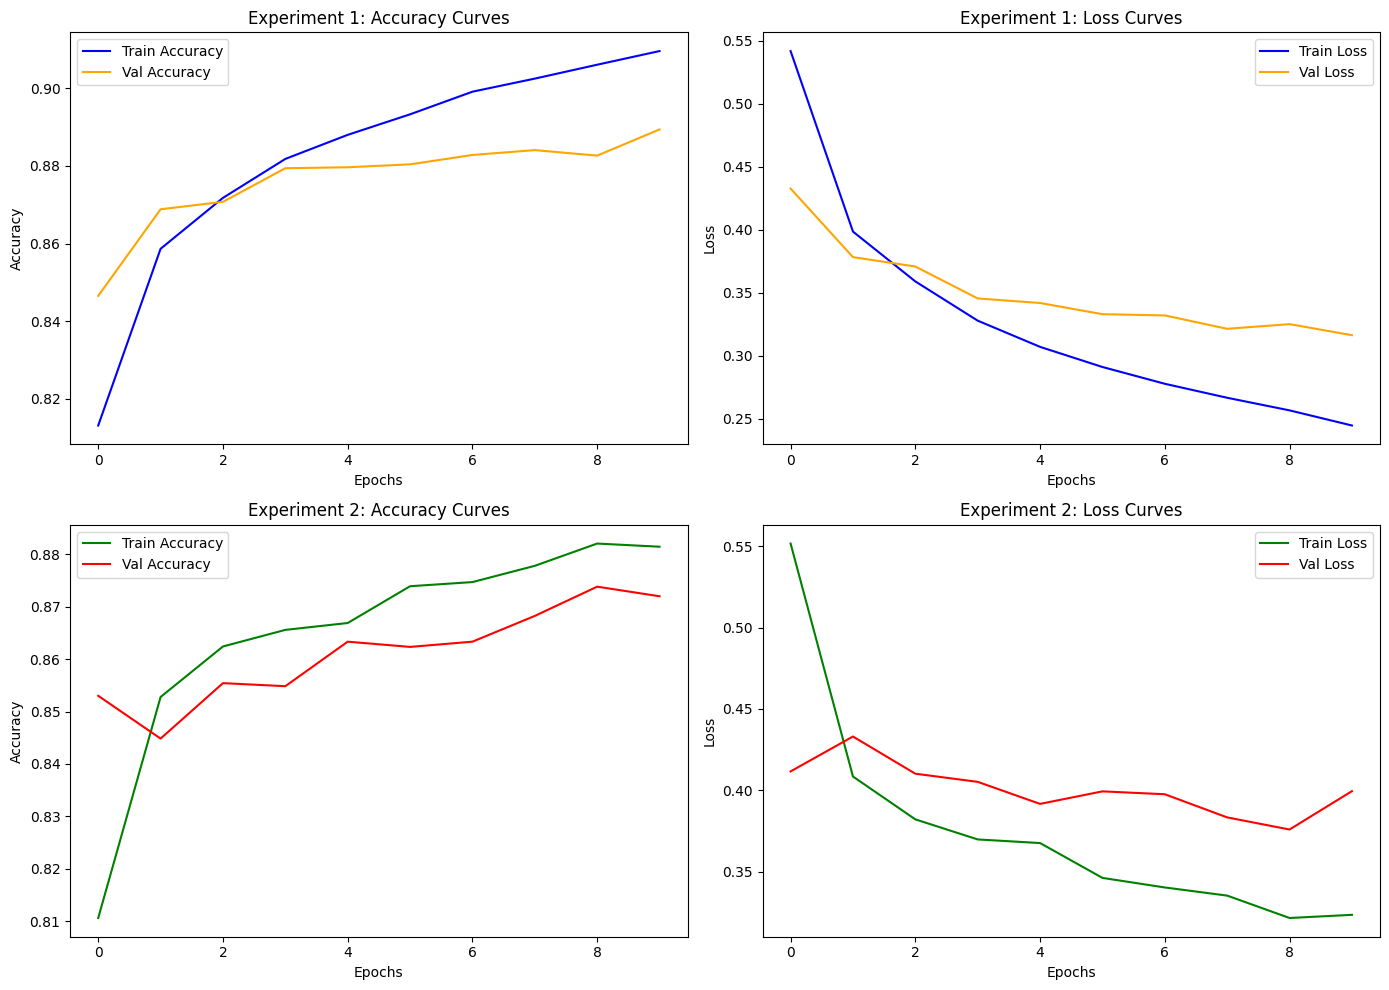

In [10]:
# Plot Accuracy and Loss curves for both experiments
plt.figure(figsize=(14, 10))

# 1. Experiment 1: Accuracy Curves / منحنى دقة التجربة الأولى
plt.subplot(2, 2, 1)
plt.plot(history_1.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_1.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Experiment 1: Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. Experiment 1: Loss Curves / منحنى فقد التجربة الأولى
plt.subplot(2, 2, 2)
plt.plot(history_1.history['loss'], label='Train Loss', color='blue')
plt.plot(history_1.history['val_loss'], label='Val Loss', color='orange')
plt.title('Experiment 1: Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 3. Experiment 2: Accuracy Curves / منحنى دقة التجربة الثانية
plt.subplot(2, 2, 3)
plt.plot(history_2.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history_2.history['val_accuracy'], label='Val Accuracy', color='red')
plt.title('Experiment 2: Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 4. Experiment 2: Loss Curves / منحنى فقد التجربة الثانية
plt.subplot(2, 2, 4)
plt.plot(history_2.history['loss'], label='Train Loss', color='green')
plt.plot(history_2.history['val_loss'], label='Val Loss', color='red')
plt.title('Experiment 2: Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()